# Importing the dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

EDA

In [5]:
web = pd.read_csv("C:\Dev\ml-projects\web-traffic-analysis\website_data.csv")

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\boluv\AppData\Local\Temp\ipykernel_7144\1820067853.py:1: SyntaxWarning: invalid escape sequence '\D'
  web = pd.read_csv("C:\Dev\ml-projects\web-traffic-analysis\website_data.csv")


In [6]:
web.head()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits,Conversion Rate
0,5,11.05,0.23,Organic,3.89,3,1.0
1,4,3.43,0.39,Social,8.48,0,1.0
2,4,1.62,0.40,Organic,9.64,2,1.0
3,5,3.63,0.18,Organic,2.07,3,1.0
4,5,4.24,0.29,Paid,1.96,5,1.0


In [30]:
web.describe()

,Page Views,Session Duration,Bounce Rate,Time on Page,Previous Visits,Conversion Rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.950500,3.021970,0.284865,4.027470,1.978500,0.982065
std,2.183903,3.104585,0.159707,2.887413,1.432852,0.065680
min,0.000000,0.000000,0.010000,0.070000,0.000000,0.343665
25%,3.000000,0.817500,0.160000,1.937500,1.000000,1.000000
50%,5.000000,1.990000,0.270000,3.320000,2.000000,1.000000
75%,6.000000,4.200000,0.390000,5.412500,3.000000,1.000000
max,14.000000,20.290000,0.840000,24.800000,9.000000,1.000000


In [9]:
web.isnull().sum()

Page Views          0
Session Duration    0
Bounce Rate         0
Traffic Source      0
Time on Page        0
Previous Visits     0
Conversion Rate     0
dtype: int64

In [18]:
web.duplicated().sum()

0

In [11]:
web.columns

Index(['Page Views', 'Session Duration', 'Bounce Rate', 'Traffic Source',
       'Time on Page', 'Previous Visits', 'Conversion Rate'],
      dtype='object')

In [12]:
web.shape

(2000, 7)

In [13]:
web.head()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits,Conversion Rate
0,5,11.05,0.23,Organic,3.89,3,1.0
1,4,3.43,0.39,Social,8.48,0,1.0
2,4,1.62,0.40,Organic,9.64,2,1.0
3,5,3.63,0.18,Organic,2.07,3,1.0
4,5,4.24,0.29,Paid,1.96,5,1.0


<Axes: xlabel='Traffic Source', ylabel='Count'>

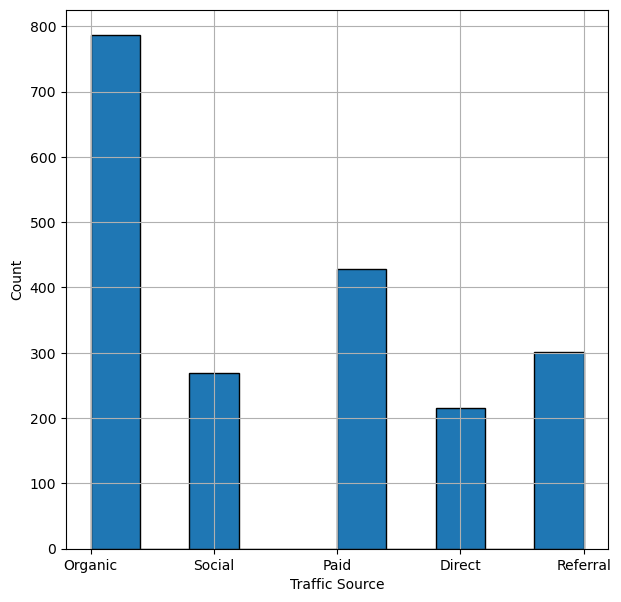

In [ ]:
# plotting a histogram to get a count of the traffic source 
plt.figure(figsize=(7,7))
plt.xlabel('Traffic Source', fontsize=10)
plt.ylabel('Count', fontsize=10)
web['Traffic Source'].hist(edgecolor = 'black')

In [19]:
web.columns.tolist()

['Page Views',
 'Session Duration',
 'Bounce Rate',
 'Traffic Source',
 'Time on Page',
 'Previous Visits',
 'Conversion Rate']

<Axes: xlabel='Conversion Rate', ylabel='Count'>

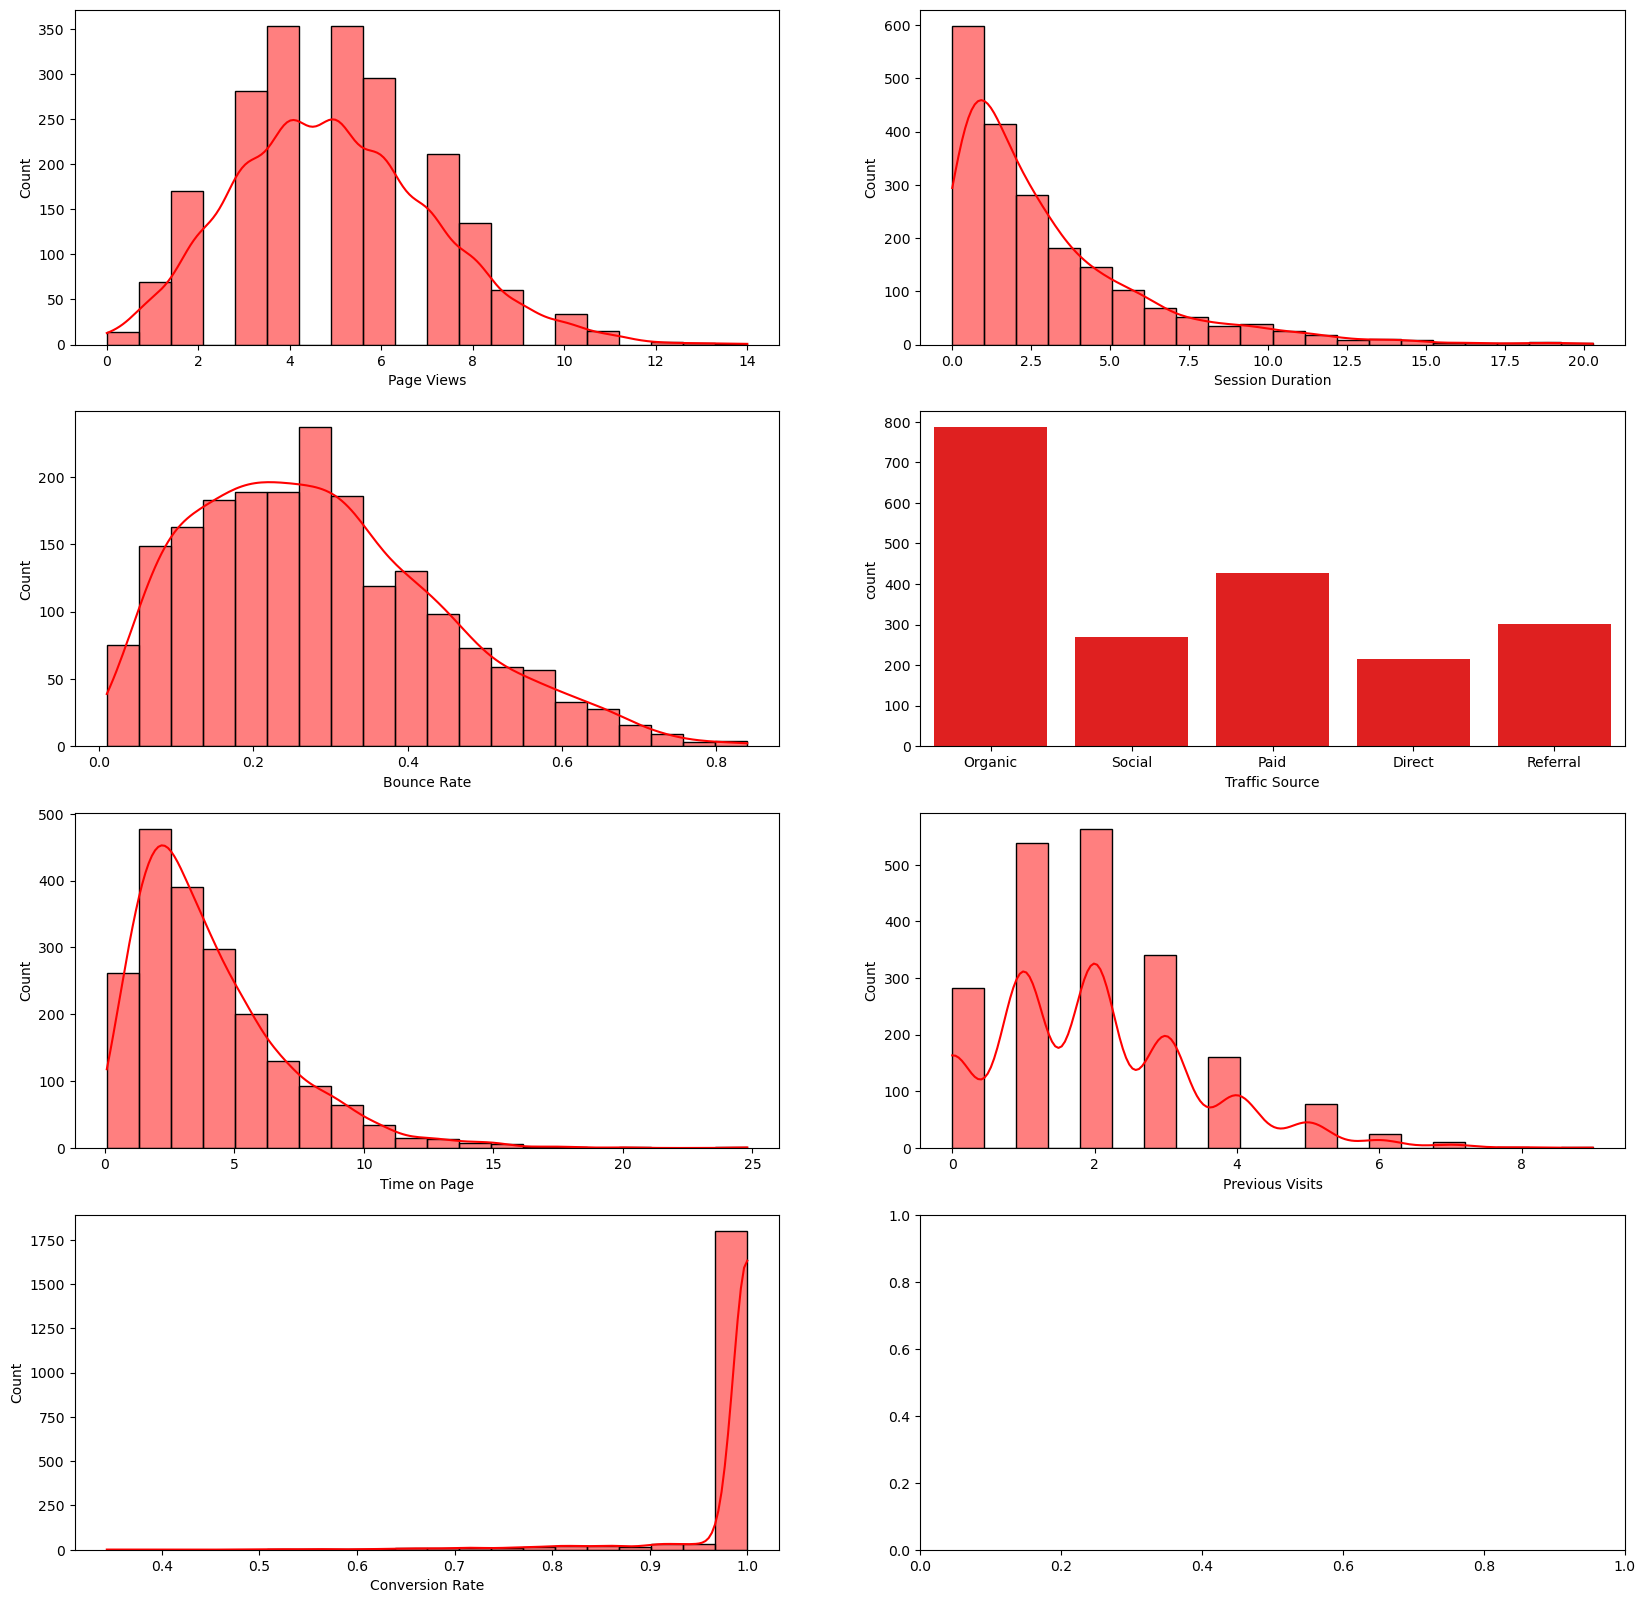

In [20]:
# density graph
fig, ax = plt.subplots(4, 2, figsize=(20,20))
sns.histplot(web['Page Views'], bins=20, kde=True, ax=ax[0,0], color='red')
sns.histplot(web['Session Duration'], bins=20, kde=True, ax=ax[0,1], color='red')
sns.histplot(web['Bounce Rate'], bins=20, kde=True, ax=ax[1,0], color='red')
sns.countplot(x=web['Traffic Source'], ax=ax[1,1], color='red')
sns.histplot(web['Time on Page'], bins=20, kde=True, ax=ax[2,0], color='red')
sns.histplot(web['Previous Visits'], bins=20, kde=True, ax=ax[2,1], color='red')
sns.histplot(web['Conversion Rate'], bins=20, kde=True, ax=ax[3,0], color='red')

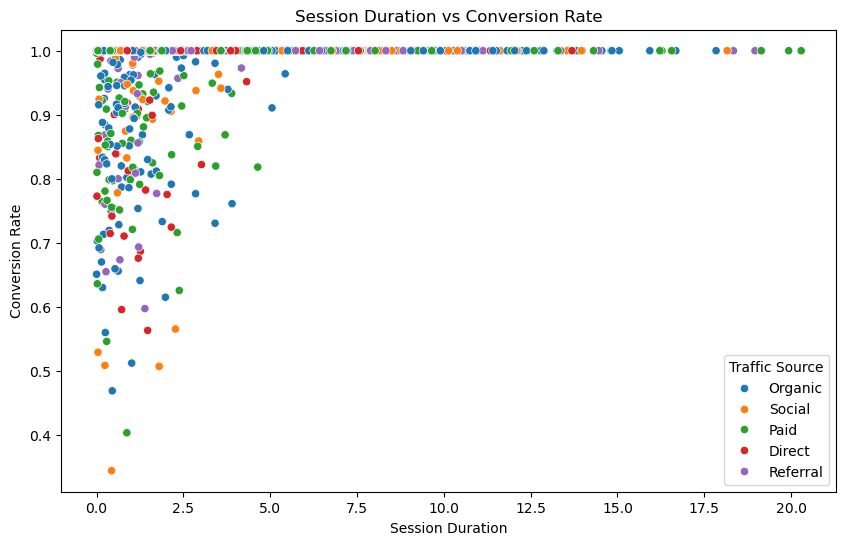

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Session Duration', y='Conversion Rate', hue='Traffic Source', data=web)
plt.title('Session Duration vs Conversion Rate')
plt.xlabel('Session Duration')
plt.ylabel('Conversion Rate')
plt.show()

In [22]:
visits_conv = web.groupby('Previous Visits')['Conversion Rate'].mean()
print(visits_conv)

Previous Visits
0    0.967540
1    0.977509
2    0.984468
3    0.990167
4    0.987881
5    0.994937
6    0.993290
7    1.000000
8    1.000000
9    1.000000
Name: Conversion Rate, dtype: float64


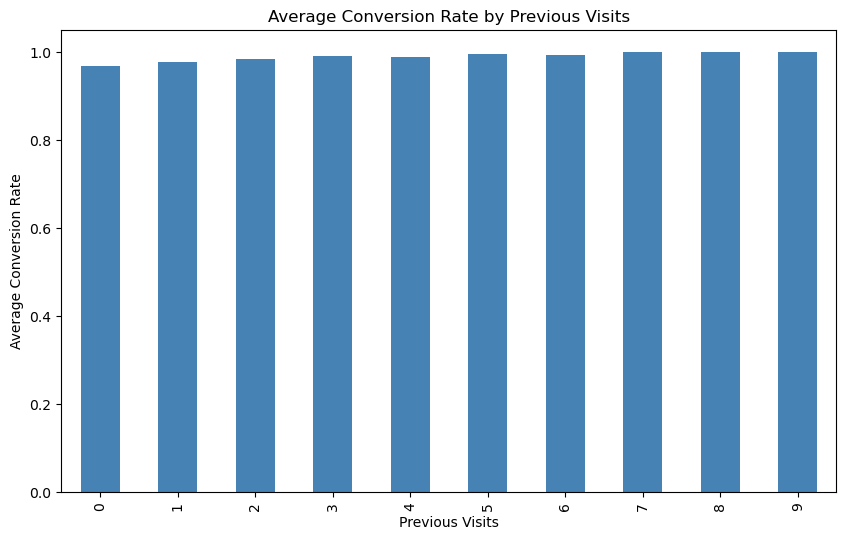

In [23]:
visits_conv.plot(kind='bar', figsize=(10,6), color='steelblue')
plt.title('Average Conversion Rate by Previous Visits')
plt.xlabel('Previous Visits')
plt.ylabel('Average Conversion Rate')
plt.show()

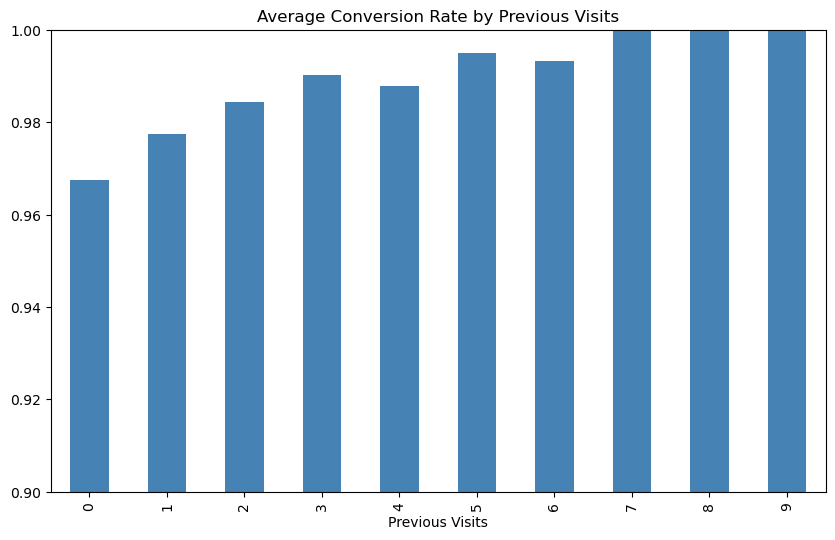

In [24]:
visits_conv.plot(kind='bar', figsize=(10,6), color='steelblue')
plt.ylim(0.9, 1.0)
plt.title('Average Conversion Rate by Previous Visits')
plt.show()

In [27]:
cor = web.corr(numeric_only=True)

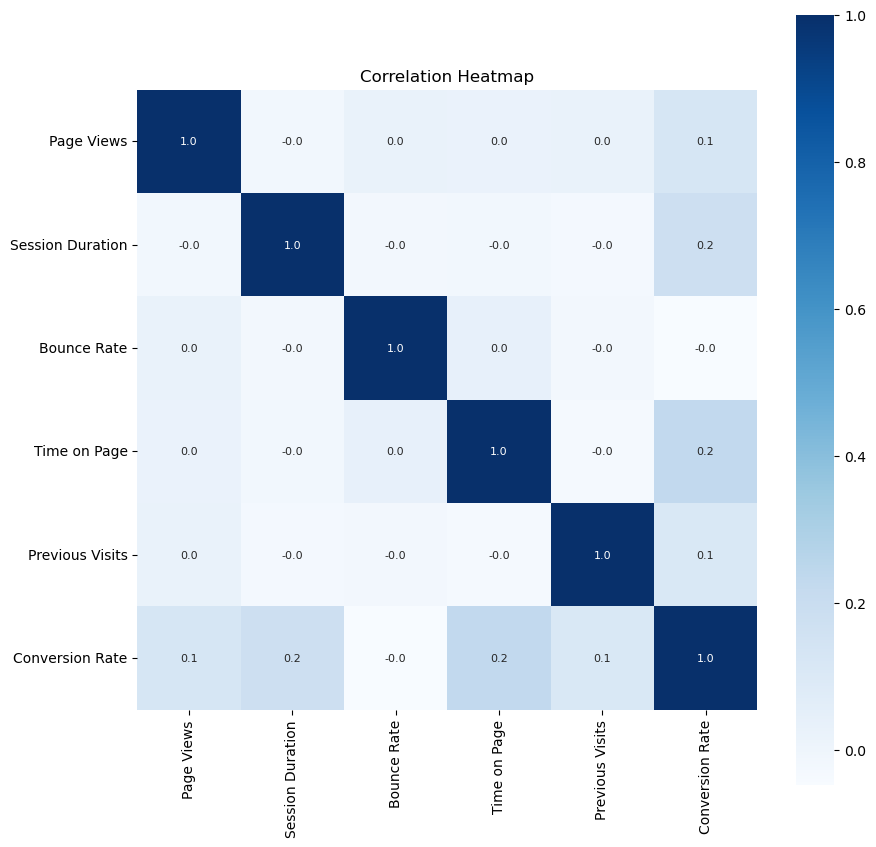

In [29]:
plt.figure(figsize=(10,10))
sns.heatmap(cor,cbar=True,square=True,fmt='.1f',annot=True, annot_kws={'size': 8}, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

Traffic Source
Referral    0.266312
Organic     0.281858
Direct      0.284537
Paid        0.296145
Social      0.296729
Name: Bounce Rate, dtype: float64


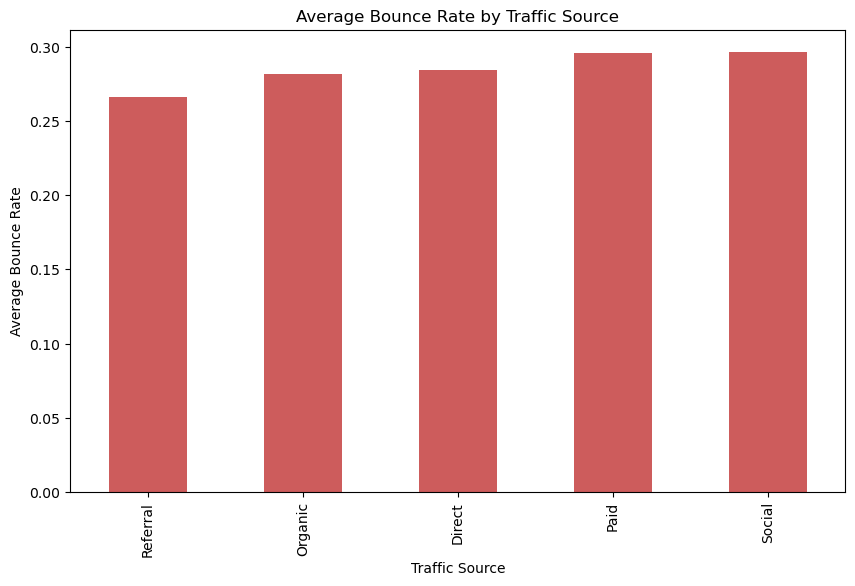

In [35]:
# Average bounce rate by traffic source
bounce_by_source = web.groupby('Traffic Source')['Bounce Rate'].mean().sort_values()
print(bounce_by_source)

bounce_by_source.plot(kind='bar', figsize=(10,6), color='indianred')
plt.title('Average Bounce Rate by Traffic Source')

plt.xlabel('Traffic Source')
plt.ylabel('Average Bounce Rate')
plt.show()

Traffic Source
Direct      0.978679
Paid        0.979009
Organic     0.982282
Social      0.982679
Referral    0.987727
Name: Conversion Rate, dtype: float64


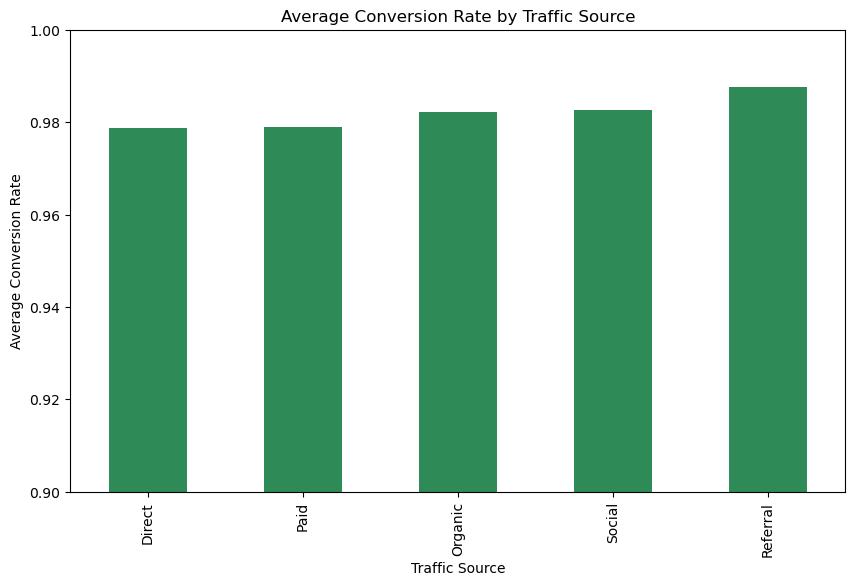

In [33]:
# Average conversion rate by traffic source
conv_by_source = web.groupby('Traffic Source')['Conversion Rate'].mean().sort_values()
print(conv_by_source)

conv_by_source.plot(kind='bar', figsize=(10,6), color='seagreen')
plt.title('Average Conversion Rate by Traffic Source')
plt.ylim(0.9, 1.0)
plt.xlabel('Traffic Source')
plt.ylabel('Average Conversion Rate')
plt.show()